## Анализ тональности

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
df.head()


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [3]:
print(df.shape)

(41157, 6)


In [4]:
df.sample(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
26554,30353,75305,Wales,02-04-2020,Advice for residents with online address probl...,Neutral
20613,24412,69364,"Johannesburg, South Africa",25-03-2020,#COSATU urges all workers and their families t...,Extremely Positive
36519,40318,85270,"Bartlett, TN",09-04-2020,?@golfspybarbajo? great article. Well done. #G...,Extremely Positive
16416,20215,65167,Mexico City,22-03-2020,#Greece will implement a nationwide ban of non...,Negative
26316,30115,75067,"Richardson, TX",02-04-2020,Armor discovers cyber underground criminals ex...,Extremely Negative
15223,19022,63974,NaN,22-03-2020,I have to recondition myself not to blow my no...,Negative
20341,24140,69092,"Washington, DC",24-03-2020,@adamdavidlong @embeddedfinance @EconTalker on...,Extremely Negative
19591,23390,68342,"Washington, DC",24-03-2020,Quick reminder that direct marketing rules cou...,Neutral
9877,13676,58628,SW Michigan,20-03-2020,'after rump said Thursday that hydroxychloroqu...,Extremely Positive
3720,7519,52471,"New York, NY London, UK",18-03-2020,While confirmed #Covid-19 cases in SSA remain ...,Negative


In [5]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df[['OriginalTweet', 'Sentiment']]
df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


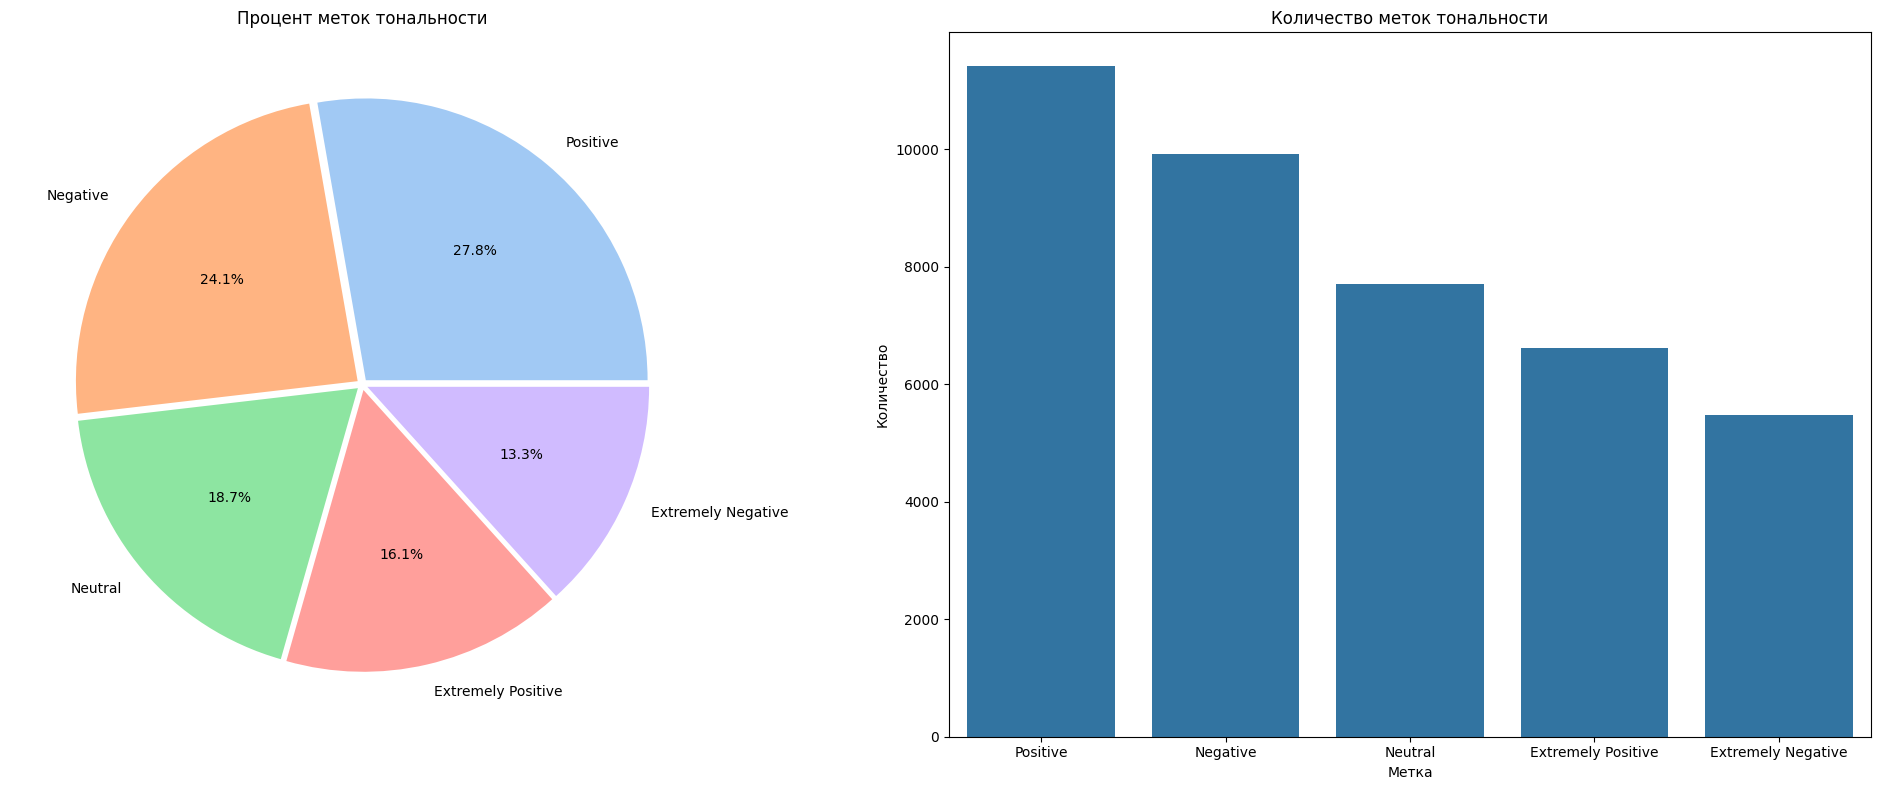

In [13]:
label_count = df['Sentiment'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,8))
color = sns.color_palette(palette='pastel')
explode = [0.02]*len(label_count)

axes[0].pie(label_count.values, labels = label_count.index, autopct='%1.1f%%', colors = color, explode=explode)
axes[0].set_title('Процент меток тональности')

sns.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Количество меток тональности')
axes[1].set_xlabel('Метка')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()


In [14]:
df['len'] = df['OriginalTweet'].apply(len)

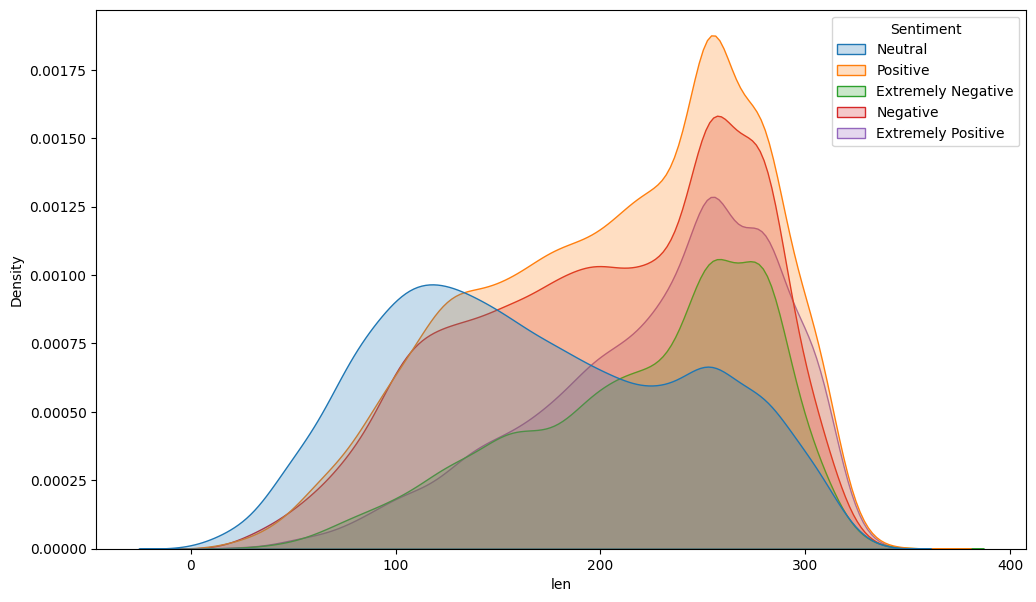

In [17]:
plt.figure(figsize=(12,7))
sns.kdeplot(df, x='len', fill=True, hue='Sentiment')
plt.show()

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
matrix = cv.fit_transform(df['OriginalTweet'])


In [19]:
matrix.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0]], shape=(41157, 80424))

In [23]:
cv.get_feature_names_out()[40057:40077]

array(['keynes', 'keynesians', 'keynpu36xz', 'keypad', 'keypads',
       'keyretailoutlets', 'keys', 'keyser', 'keystone', 'keystonemn',
       'keyword', 'keywords', 'keyworker', 'keyworkerheroes',
       'keyworkers', 'keyworkersonly', 'keyworking', 'kezelee',
       'kf5kaze6yy', 'kf5nr6ukkc'], dtype=object)

In [24]:
word_matrix = pd.DataFrame(matrix.toarray(), columns=cv.get_feature_names_out())


In [25]:
print(word_matrix)

       00  000  0000  0000009375  0000hrs  000162  00042  000cr  000francs  \
0       0    0     0           0        0       0      0      0          0   
1       0    0     0           0        0       0      0      0          0   
2       0    0     0           0        0       0      0      0          0   
3       0    0     0           0        0       0      0      0          0   
4       0    0     0           0        0       0      0      0          0   
...    ..  ...   ...         ...      ...     ...    ...    ...        ...   
41152   0    0     0           0        0       0      0      0          0   
41153   0    0     0           0        0       0      0      0          0   
41154   0    0     0           0        0       0      0      0          0   
41155   0    0     0           0        0       0      0      0          0   
41156   2    0     0           0        0       0      0      0          0   

       000ksh  ...  zzxwzxhc2v  zzz  zzzz  zâ  zã  zã¼rich  â² 

In [26]:
df_sum = word_matrix.sum(axis=0, skipna=True)
bow = df_sum.sort_values(ascending=False)[:30]
bow = pd.DataFrame(bow, columns=['Frequency'])

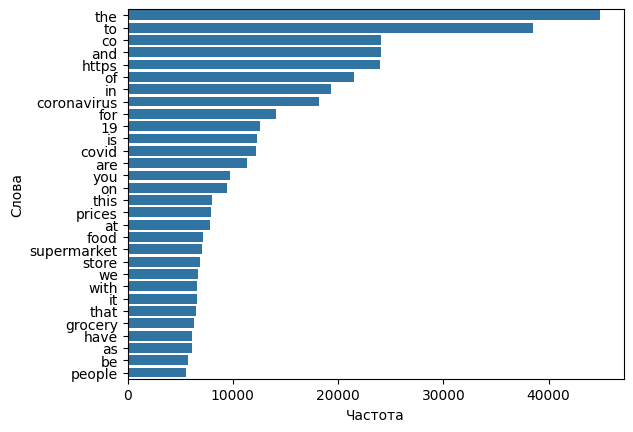

In [27]:
sns.barplot(x=bow['Frequency'], y=bow.index)
plt.xlabel('Частота')
plt.ylabel('Слова')
plt.show()

In [34]:
import nltk
for i in ['punkt', 'stopwords']:
    nltk.download(i)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/artemgolubnichiy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/artemgolubnichiy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
import string 
import nltk
import re 

def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'pic.\S+', '', text)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    text = re.sub(r"\s+ [^a-zA-Z']\s+", ' ', text+ " ")
    text = ''.join([i for i in text if i not in string.punctuation])
    words = nltk.tokenize.word_tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')
    text = ' '.join([i for i in words if i not in stopwords and len(i)])
    text = re.sub('\s[\s]+', ' ', text).strip()
    return text


In [31]:
df['new_text'] = df['OriginalTweet'].apply(clean_text)

In [32]:
df['OriginalTweet'].iloc[189]

'When panic buying(thanks to the media) think of the elderly or those with disabilities who canÂ\x92t get out to buy food and essentials. #covid?19uk  #coronavirus #panicshopping https://t.co/1iAwpNs096'

In [33]:
df['new_text'].iloc[189]

'panic buying thanks media think elderly disabilities get buy food essentials covid uk coronavirus panicshopping'

In [35]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

ps = PorterStemmer()
words = word_tokenize(df['new_text'].iloc[1])
for w in words:
    print(w, ':', ps.stem(w))

advice : advic
talk : talk
neighbours : neighbour
family : famili
exchange : exchang
phone : phone
numbers : number
create : creat
contact : contact
list : list
phone : phone
numbers : number
neighbours : neighbour
schools : school
employer : employ
chemist : chemist
gp : gp
set : set
online : onlin
shopping : shop
accounts : account
poss : poss
adequate : adequ
supplies : suppli
regular : regular
meds : med
order : order


In [36]:
stemmed = []
for i in range(len(df)):
    stem_list = []
    words = word_tokenize(df['new_text'].iloc[i])
    for w in words:
        stem_list.append(ps.stem(w))
    stemmed.append(stem_list)

df['Stemmed'] = stemmed
df.head()

,OriginalTweet,Sentiment,len,new_text,Stemmed
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,,[]
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia woolworths give elderly ...,"[coronaviru, australia, woolworth, give, elder..."
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty please dont panic enough ...,"[food, stock, one, empti, pleas, dont, panic, ..."
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,ready go supermarket covid outbreak im paranoi...,"[readi, go, supermarket, covid, outbreak, im, ..."


In [37]:
df['Stemmed'] = df['Stemmed'].apply(' '.join)
df.head()

,OriginalTweet,Sentiment,len,new_text,Stemmed
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,,
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...,advic talk neighbour famili exchang phone numb...
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia woolworths give elderly ...,coronaviru australia woolworth give elderli di...
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty please dont panic enough ...,food stock one empti pleas dont panic enough f...
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,ready go supermarket covid outbreak im paranoi...,readi go supermarket covid outbreak im paranoi...


### Наивный Байес

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


In [39]:
X = df['Stemmed']
y, class_names = pd.factorize(df['Sentiment'], sort=True)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)


In [ ]:
pipe_1 = Pipeline([('vectorizer', TfidfVectorizer()), ('classifire', MultinomialNB(alpha=0.005))])

In [42]:
pipe_1.fit(X_train, y_train)
y_pred = pipe_1.predict(X_test)

In [43]:
print(accuracy_score(y_test, y_pred))

0.4316083576287658


In [44]:
print(classification_report(y_test, y_pred, target_names=class_names))

                    precision    recall  f1-score   support

Extremely Negative       0.52      0.32      0.39      1096
Extremely Positive       0.48      0.32      0.38      1325
          Negative       0.40      0.49      0.44      1983
           Neutral       0.55      0.35      0.43      1543
          Positive       0.39      0.56      0.46      2285

          accuracy                           0.43      8232
         macro avg       0.47      0.41      0.42      8232
      weighted avg       0.45      0.43      0.43      8232



### Логистическая регрессия

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
pipe_2 = Pipeline([('vectorizer', TfidfVectorizer()), ('classifire', LogisticRegression())])
pipe_2.fit(X_train, y_train)
y_pred = pipe_2.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

0.5880709426627794
                    precision    recall  f1-score   support

Extremely Negative       0.66      0.53      0.59      1096
Extremely Positive       0.69      0.58      0.63      1325
          Negative       0.53      0.53      0.53      1983
           Neutral       0.63      0.68      0.65      1543
          Positive       0.54      0.61      0.57      2285

          accuracy                           0.59      8232
         macro avg       0.61      0.59      0.59      8232
      weighted avg       0.59      0.59      0.59      8232



/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
